### SETUP

In [3]:
from ultralytics import YOLO
from torch.cuda import empty_cache

# For 3.13 versions or lower
try:
    import albumentations as A

    custom_transforms = [
        # Blur variations
        A.OneOf(
            [
                A.MotionBlur(blur_limit=7, p=1.0),
                A.MedianBlur(blur_limit=7, p=1.0),
                A.GaussianBlur(blur_limit=7, p=1.0),
            ],
            p=0.3,
        ),

        # Noise variations
        A.OneOf(
            [
                A.GaussNoise(var_limit=(10.0, 50.0), p=1.0),
                A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=1.0),
            ],
            p=0.2,
        ),

        # Color and contrast adjustments
        A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
        A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),

        # Simulate occlusions
        A.CoarseDropout(
            max_holes=8, max_height=32, max_width=32, min_holes=1, min_height=8, min_width=8, fill_value=0, p=0.2
        ),
    ]
except ModuleNotFoundError:
    print('Albumentations only supports Python versions 3.9 - 3.14.0')
    custom_transforms = []

C:\Users\Bui Thien Nghia\AppData\Local\Temp\ipykernel_18428\2946918329.py:22: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=1.0),
C:\Users\Bui Thien Nghia\AppData\Local\Temp\ipykernel_18428\2946918329.py:34: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


### DATASET PREVIEW

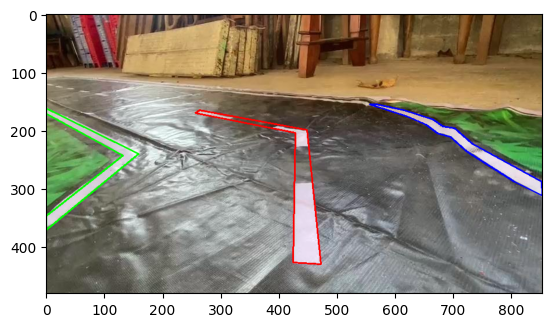

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

lane_map = {
    0: (255, 0, 0),
    1: (0, 255, 0),
    2: (0, 0, 255)
}

img_path = 'D:\\BFMC2026\\YOLO_SEG_LANE\\train\\images\\frame_1_jpg.rf.c8e0532e2c6f187416fde99e588cc1ce.jpg'
lbl_path = 'D:\\BFMC2026\\YOLO_SEG_LANE\\train\\labels\\frame_1_jpg.rf.c8e0532e2c6f187416fde99e588cc1ce.txt'

img = cv2.imread(img_path)
h, w, c = img.shape
with open(lbl_path, 'r') as f:
    for line in f:
        l = line.strip().split()
        cls = int(l[0])
        pts = np.array(l[1:], dtype=np.float32).reshape(-1, 2) * [w, h]
        pts = pts.astype(np.int32)

        for p in pts:
            cv2.polylines(img, [pts], True, lane_map[cls], 2)

plt.imshow(img)
plt.show()

### TRAINING

In [4]:
model = YOLO('model/lane/weights/best.pt')
# model = YOLO('yolo26n-seg.pt')
model.train(
    data='data-seg.yaml',
    cfg='trainconfig.yaml',
    # augmentations=custom_transforms,
)

New https://pypi.org/project/ultralytics/8.4.8 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.6  Python-3.14.0 torch-2.9.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=trainconfig.yaml, classes=None, close_mosaic=30, cls=1.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.15, data=data-seg.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=True, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=model/lane/weights/best.pt, momentum=0.937, mosaic=1, multi_scale=True, name=l

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000206EB37B7E0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    

### VALIDATING

In [ ]:
model = YOLO('model/lane/weights/best.pt')
model.val(
    data='data.yaml',
    cfg='trainconfig.yaml',
    split='test'
)

Ultralytics 8.4.6  Python-3.14.0 torch-2.9.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
YOLO26s summary (fused): 122 layers, 9,471,759 parameters, 0 gradients, 20.6 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 598.9431.4 MB/s, size: 506.1 KB)
val: Scanning D:\BFMC2026\YOLO_UNIFIED\labels\test.cache... 20769 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20769/20769 5.8Git/s 0.0s
val: D:\BFMC2026\YOLO_UNIFIED\images\test\LISA_nightClip4--00383.jpg: 1 duplicate labels removed
val: D:\BFMC2026\YOLO_UNIFIED\images\test\LISA_nightClip4--00391.jpg: 1 duplicate labels removed
val: D:\BFMC2026\YOLO_UNIFIED\images\test\LISA_nightSequence2--00761.jpg: 1 duplicate labels removed
val: D:\BFMC2026\YOLO_UNIFIED\images\test\LISA_nightSequence2--06373.jpg: 1 duplicate labels removed
val: D:\BFMC2026\YOLO_UNIFIED\images\test\LISA_nightSequence2--06406.jpg: 1 duplicate labels removed
val: D:\BFMC2026\YOLO_UNIFIED\images\test\LISA_nightSequence2--06442.jpg: 1 duplicate labe

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000146DC50BC50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    

### PREDICTING

### EXPORTING MODEL

In [4]:
model = YOLO('model/lane/weights/best.pt')
model.export(
    format='onnx',
    imgsz=416,
    dynamic=False,
    half=True,
    simplify=True
)
model.export(
    format='ncnn',
    imgsz=416,
    half=True
)

Ultralytics 8.4.6  Python-3.14.0 torch-2.9.0+cu130 CPU (Intel Core(TM) i5-10210U 1.60GHz)
YOLO26n-seg summary (fused): 139 layers, 2,689,469 parameters, 0 gradients, 9.0 GFLOPs

PyTorch: starting from 'model\lane\weights\best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) ((1, 300, 38), (1, 32, 104, 104)) (6.2 MB)

ONNX: starting export with onnx 1.20.0 opset 22...


C:\Users\Bui Thien Nghia\AppData\Roaming\Python\Python314\site-packages\torch\onnx\_internal\torchscript_exporter\utils.py:1447: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: slimming with onnxslim 0.1.82...


C:\Users\Bui Thien Nghia\AppData\Roaming\Python\Python314\site-packages\torch\onnx\_internal\torchscript_exporter\symbolic_opset9.py:5353: UserWarning: Exporting aten::index operator of advanced indexing in opset 22 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  warnings.warn(


ONNX: converting to FP16...
ONNX: export success  3.7s, saved as 'model\lane\weights\best.onnx' (5.3 MB)

Export complete (4.0s)
Results saved to C:\Users\Bui Thien Nghia\Documents\PERSONAL FILES 2\Cholibi-BFMC2026\lab_n_archives\model\lane\weights
Predict:         yolo predict task=segment model=model\lane\weights\best.onnx imgsz=416 half
Validate:        yolo val task=segment model=model\lane\weights\best.onnx imgsz=416 data=data-seg.yaml half 
Visualize:       https://netron.app
Ultralytics 8.4.6  Python-3.14.0 torch-2.9.0+cu130 CPU (Intel Core(TM) i5-10210U 1.60GHz)
WARNING NCNN export does not support end2end models, disabling end2end branch.
YOLO26n-seg summary (fused): 165 layers, 2,971,881 parameters, 0 gradients, 9.0 GFLOPs

PyTorch: starting from 'model\lane\weights\best.pt' with input shape (1, 3, 416, 416) BCHW and output shape(s) ((1, 39, 3549), (1, 32, 104, 104)) (6.2 MB)

NCNN: starting export with NCNN 1.0.20260114 and PNNX 20260112...
NCNN: export success  5.8s, saved 

'model\\lane\\weights\\best_ncnn_model'